## Imports

In [43]:
import math , random
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import ImageDraw , Image
from matplotlib import pyplot as plt
import numpy as np

In [44]:
# some constants
IMG_SIZE = 32
EMBEDDED_DIM = 64
ATTENTION_HEADS = 8
EPOCHS = 10
BATCH_SIZE = 4
LR = 3e-4
TEMPERATURE = 0.07

In [45]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

## Synthetic dataset properties.

In [46]:
colors = ['red' , 'green' , 'blue' , 'yellow' , 'purple' , 'orange' , 'pink' , 'brown' , 'gray']
shapes = ['square' , 'circle' , 'triangle']
positions = ['left' , 'center' , 'right' , 'top' , 'bottom' , 'top-left' , 'top-right' , 'bottom-left' , 'bottom-right']

## Drawing image shapes

In [47]:
def draw_sample(color , shape , position , img_size = IMG_SIZE):
    img = Image.new('RGB' ,(img_size , img_size) , 'white')
    draw = ImageDraw.Draw(img)

    margin = 6
    h = w = img_size -2*margin

    # calculate x coordinates
    if 'left' in position or 'top-left' in position or 'bottom-left' in position:
        x0 = margin
        x1 = margin + w // 2
    elif 'right' in position or 'top-right' in position or 'bottom-right' in position:
        x0 = margin + w // 2
        x1 = img_size - margin
    else:
        x0 = margin + w // 4
        x1 = margin + 3 * w // 4

    # calculate y coordinates
    if 'top' in position or 'top-left' in position or 'top-right' in position:
        y0 = margin
        y1 = margin + h // 2
    elif 'bottom' in position or 'bottom-left' in position or 'bottom-right' in position:
        y0 = margin + h // 2
        y1 = img_size - margin
    else:
        y0 = margin + h // 4
        y1 = margin + 3 * h // 4

    # select shape
    if shape == 'square':
        draw.rectangle([x0,y0,x1,y1] ,fill = color , outline = 'black')
    elif shape == 'circle':
        draw.ellipse([x0, y0, x1, y1], fill=color, outline='black')
    else: # triangle
        draw.polygon([(x0 + (x1 - x0) // 2 , y0) , (x0 , y1) , (x1 , y1)] , fill = color , outline = 'black')
    return img

## Class for building the dataset(image and caption)

In [48]:
class ShapesDataset():
    def __init__(self):
        self.images = []
        self.captions = []

        # generate all combinations
        for c in colors:
            for s in shapes:
                for p in positions:
                    img = draw_sample(c, s, p)
                    cap = f"{c} {s} {p}"

                    self.images.append(
                        torch.from_numpy(np.asarray(img))
                        .permute(2, 0, 1)
                        .float() / 255.0
                    )
                    self.captions.append(cap)

        # build vocab AFTER captions are ready
        self.vocab, self.word2index = self.build_vocab(self.captions)

    def build_vocab(self, texts):
        words = sorted({w for t in texts for w in t.split()})
        vocab = ['[CLS]'] + words
        word2index = {w: i for i, w in enumerate(vocab)}
        return vocab, word2index

    def encode_text(self, text):
        tokens = [self.word2index['[CLS]']] + \
                 [self.word2index[w] for w in text.split()]
        return torch.tensor(tokens, dtype=torch.long)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        return (
            self.images[index],
            self.encode_text(self.captions[index]),
            self.captions[index]
        )

In [49]:
dataset = ShapesDataset()
VOCAB_SIZE = len(dataset.vocab)
VOCAB_SIZE

22

## Train and validation data split

In [50]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

In [51]:
train_ds, val_ds = torch.utils.data.random_split(
    dataset,
    [train_size, val_size]
)

## Data Loader

In [52]:
from torch.utils.data import DataLoader
train_loader = DataLoader(
    train_ds,
    batch_size = BATCH_SIZE,
    shuffle = True
)
val_loader = DataLoader(
    val_ds,
    batch_size = BATCH_SIZE,
    shuffle = True
)

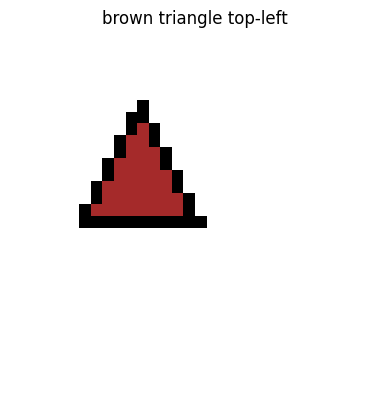

In [53]:
# a sample image
images, tokens, captions = next(iter(train_loader))
# take first sample in batch
img = images[0]
img = img.permute(1, 2, 0).numpy()

plt.imshow(img)
plt.title(captions[0])
plt.axis("off")
plt.show()

## Image Encoder

In [54]:
class ImageEncoder(nn.Module):
    def __init__(self , embed_dim = EMBEDDED_DIM):
        super().__init__()
        self.convLayers = nn.Sequential(
            nn.Conv2d(3 , 32 , 3 , 2 , 1),
            nn.ReLU(),
            nn.Conv2d(32 , 64 , 3 , 2 , 1),
            nn.ReLU(),
            nn.Conv2d(64 , 128 , 3 , 2 , 1),
            nn.ReLU(),
            nn.Conv2d(128 , 256 , 3 , 2 , 1),
            nn.ReLU()
        )

        self.projection = nn.Linear(256 , embed_dim)
        self.layernorm1 = nn.LayerNorm(embed_dim)

    def forward(self , x):
        x = self.convLayers(x)
        x = x.mean(dim = [2 , 3]) # global avg pooling
        x = self.projection(x)
        x = F.normalize(self.layernorm1(x) , dim = -1)
        return x

## Text Encoder

In [61]:
class TextEncoder(nn.Module):
    def __init__(self ,
        embed_dim = EMBEDDED_DIM,
        num_head = ATTENTION_HEADS,
        vocab_size = VOCAB_SIZE,
        context_window = 4
    ):
        super().__init__()
        
        self.token_embedding = nn.Embedding(vocab_size , embed_dim)
        self.position_embedding = nn.Embedding(context_window , embed_dim)
        
        self.attention = nn.MultiheadAttention(
            embed_dim, 
            num_head,
            batch_first = True
        )
        self.layerNorm = nn.LayerNorm(embed_dim)
        # projection to joint embedding space
        self.projection = nn.Linear(embed_dim , embed_dim)

    def forward(self , tokens):
        N , L = tokens.shape
        position_embedding_ids = torch.arange(
            L , device = tokens.device
        ).unsqueeze(0).expand(N , L)

        tokens_embedding_vectors = self.token_embedding(tokens)
        position_embedding_vectors = self.position_embedding(position_embedding_ids)

        final_embedding = tokens_embedding_vectors + position_embedding_vectors
        # get the contextual embedding vectors
        attention_output , _ = self.attention(
            final_embedding , final_embedding , final_embedding # Q,K,V
        )

        x = self.layerNorm(attention_output)
        # CLS token
        cls_token_vectors = x[: , 0]
        x = self.layerNorm(cls_token_vectors)
        x = self.projection(x)
        x = F.normalize(x , dim = -1)
        return x

### CLIP Loss

In [62]:
def clip_loss(image_emb , text_emb , temperature = TEMPERATURE):
    logits =  image_emb @ text_emb.T / temperature
    targets = torch.arange(image_emb.size(0) , device = image_emb.device)
    loss_i = F.cross_entropy(logits , targets)
    loss_t = F.cross_entropy(logits.T , targets)
    return (loss_i + loss_t)/2.0

### Model

In [63]:
image_encoder = ImageEncoder().to(device)
text_encoder = TextEncoder().to(device)

In [64]:
# define optimizer
params = list(image_encoder.parameters()) + list(text_encoder.parameters())
optimizer = torch.optim.AdamW(params = params , lr = LR)

In [65]:
def show_image(t , title = None):
    img = (t.permute(1,2,0).numpy()*255).astype(np.uint8)
    plt.figure(figsize = (2.2,2.2))
    plt.axis('off')
    if title:
        plt.title(title , fontsize = 8)
    plt.imshow(img)
    plt.show()

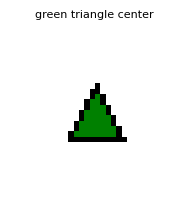

Caption: green triangle center
Image Embedding (first 8 dims):
[ 0.2124188  -0.08894438 -0.09522142 -0.15347448 -0.03972739  0.12080974
  0.07334366  0.00624661]
Text Embedding (first 8 dims):
[ 0.24869452 -0.22323827  0.00952638 -0.08455607  0.13917898 -0.07590073
  0.15920651 -0.32820183]
--------------------------------------------------


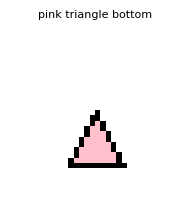

Caption: pink triangle bottom
Image Embedding (first 8 dims):
[ 0.210378   -0.08718703 -0.09133394 -0.15122359 -0.03724752  0.12198243
  0.07248738  0.00677043]
Text Embedding (first 8 dims):
[ 0.28987667 -0.24250643 -0.02748888 -0.04745642  0.2392894   0.01513424
  0.20070302 -0.3541898 ]
--------------------------------------------------


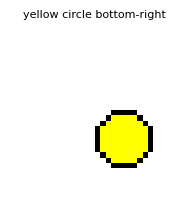

Caption: yellow circle bottom-right
Image Embedding (first 8 dims):
[ 0.21034688 -0.08673055 -0.09429968 -0.15241322 -0.03824688  0.12466612
  0.07126049  0.00849483]
Text Embedding (first 8 dims):
[ 0.07376324 -0.13247757  0.01849512 -0.09978653  0.08492967 -0.09110249
  0.06824864 -0.32205212]
--------------------------------------------------


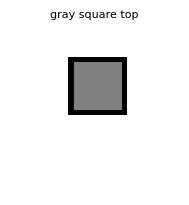

Caption: gray square top
Image Embedding (first 8 dims):
[ 0.21075875 -0.0902445  -0.09375733 -0.15051484 -0.04204649  0.11514384
  0.06735031  0.01416549]
Text Embedding (first 8 dims):
[ 0.2922606  -0.10331945 -0.01938444  0.02846742  0.14411892 -0.03490327
  0.10748396 -0.23137167]
--------------------------------------------------
tensor([[-0.0127,  0.1236, -0.0813,  0.1377],
        [-0.0106,  0.1268, -0.0807,  0.1414],
        [-0.0113,  0.1258, -0.0810,  0.1396],
        [-0.0145,  0.1225, -0.0845,  0.1385]], device='cuda:0')


In [66]:
image_encoder.eval()
text_encoder.eval()

images, tokens, captions = next(iter(train_loader))
images = images.to(device)
tokens = tokens.to(device)

with torch.no_grad():
    image_emb = image_encoder(images)
    text_emb = text_encoder(tokens)
    

for i in range(len(images)):
    
    show_image(images[i].cpu(), captions[i])

    print("Caption:", captions[i])
    print("Image Embedding (first 8 dims):")
    print(image_emb[i][:8].cpu().numpy())

    print("Text Embedding (first 8 dims):")
    print(text_emb[i][:8].cpu().numpy())

    print("-"*50)
    
# similarity matrix
sim = image_emb @ text_emb.T
print(sim)

### Validation function

In [67]:
def validate():

    image_encoder.eval()
    text_encoder.eval()

    total_loss = 0

    with torch.no_grad():

        for images, tokens, _ in val_loader:

            images = images.to(device)
            tokens = tokens.to(device)

            image_emb = image_encoder(images)
            text_emb = text_encoder(tokens)

            loss = clip_loss(image_emb, text_emb)

            total_loss += loss.item()

    avg_loss = total_loss / len(val_loader)

    print(f"Validation Loss: {avg_loss:.4f}")

### Training Loop

In [68]:
for epoch in range(EPOCHS):
    image_encoder.train()
    text_encoder.train()
    
    total_loss = 0
    
    for images , tokens , captions in train_loader:
        images = images.to(device)
        tokens = tokens.to(device)
        
        optimizer.zero_grad()
        
        # forward
        image_emb = image_encoder(images)
        text_emb = text_encoder(tokens)
        loss = clip_loss(image_emb , text_emb)
        
        # backward
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_train_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f}")
    validate()

Epoch 1/10 | Train Loss: 1.3584
Validation Loss: 1.0630
Epoch 2/10 | Train Loss: 0.7725
Validation Loss: 0.4003
Epoch 3/10 | Train Loss: 0.2182
Validation Loss: 0.3831
Epoch 4/10 | Train Loss: 0.2034
Validation Loss: 0.2151
Epoch 5/10 | Train Loss: 0.2261
Validation Loss: 0.1018
Epoch 6/10 | Train Loss: 0.1541
Validation Loss: 0.1901
Epoch 7/10 | Train Loss: 0.1425
Validation Loss: 0.1522
Epoch 8/10 | Train Loss: 0.1474
Validation Loss: 0.1682
Epoch 9/10 | Train Loss: 0.1456
Validation Loss: 0.2168
Epoch 10/10 | Train Loss: 0.1456
Validation Loss: 0.1413


In [69]:
images, tokens, captions = next(iter(val_loader))

images = images.to(device)
tokens = tokens.to(device)

with torch.no_grad():

    image_emb = image_encoder(images)
    text_emb = text_encoder(tokens)

sim = image_emb @ text_emb.T

print("similarity score:" , sim)

similarity score: tensor([[ 0.4902, -0.2438, -0.2776,  0.3308],
        [-0.1147,  0.6635,  0.0202, -0.2509],
        [-0.6483, -0.0622,  0.7320,  0.0699],
        [-0.0600, -0.2975,  0.3010,  0.7618]], device='cuda:0')


In [71]:
# Build Retrieval Embedding Index
def build_index(dataset):
    """This precomputes embeddings for all dataset samples"""
    image_encoder.eval()
    text_encoder.eval()
    
    all_image_emb = []
    all_text_emb = []
    all_captions = []
    all_images = []
    
    with torch.no_grad():
        for img , tokens , caption in dataset:
            img = img.unsqueeze(0).to(device)
            tokens = tokens.unsqueeze(0).to(device)
            
            # get the embeddings
            img_emb = image_encoder(img)
            txt_emb = text_encoder(tokens)
            
            all_image_emb.append(img_emb.cpu())
            all_text_emb.append(txt_emb.cpu())
            all_images.append(img.cpu())
            all_captions.append(caption)
    
    image_matrix = torch.cat(all_image_emb)
    text_matrix = torch.cat(all_text_emb)
    return image_matrix, text_matrix, all_images, all_captions

In [72]:
image_index, text_index, images_store, captions_store = build_index(dataset)

In [73]:
def caption_to_image(query_caption):

    tokens = dataset.encode_text(query_caption).unsqueeze(0).to(device)

    text_encoder.eval()

    with torch.no_grad():
        query_emb = text_encoder(tokens).cpu()

    sim = query_emb @ image_index.T
    best_idx = sim.argmax().item()

    print("Query Caption:", query_caption)
    print("Best Match Caption:", captions_store[best_idx])
    print("Similarity:", sim[0, best_idx].item())

    show_image(images_store[best_idx][0], captions_store[best_idx])

In [74]:
def image_to_caption(query_image):

    img = query_image.unsqueeze(0).to(device)

    image_encoder.eval()

    with torch.no_grad():
        img_emb = image_encoder(img).cpu()

    sim = img_emb @ text_index.T
    best_idx = sim.argmax().item()

    print("Predicted Caption:", captions_store[best_idx])
    print("Similarity:", sim[0, best_idx].item())

    show_image(query_image.cpu(), captions_store[best_idx])

Query Caption: red square left
Best Match Caption: blue square left
Similarity: 0.7330933809280396


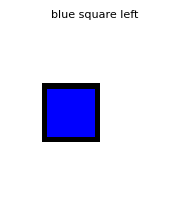

In [75]:
caption_to_image("red square left")

Predicted Caption: brown circle center
Similarity: 0.8100875616073608


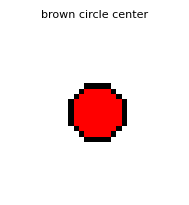

In [76]:
img, _, cap = dataset[10]

image_to_caption(img)